In [3]:
import pandas as pd 
import os 
import scanpy as sc
import scipy
import numpy as np
import matplotlib.pyplot as plt
import os
import scrublet as scr
import anndata as ad
import math
from sklearn.linear_model import LinearRegression
import statistics
import seaborn as sns


# when doing uMAP or PCA the genes need to be columns, samples are the rows

In [5]:
df = pd.read_csv('pbmc_6Kcells_500genes.txt', delimiter='\t') # peripheral blood mononuclear cells like lymphocytes and monocytes

In [6]:
df.index = df['CELLID']

In [7]:
df.drop(columns=['CELLID'], inplace=True)

In [44]:
adata = sc.AnnData(df)

In [9]:
adata_T = adata.T

In [10]:
adata_T_array = adata_T

In [11]:
print(type(adata.X))

<class 'numpy.ndarray'>


In [12]:
# need to find the median library size
# thus, need to find the library size for each cell
# library size for a cell is the number of transcripts per cell

# this is imporatnt because in RNA-seq, each sample has a
# different library size due to sequencing depth differences/sample prepping
# thus, we need to normalize for library size
# if we didn't it might look like a sample with twice as many reads 
# has twice as much expression for each gene


In [13]:
cell_library_size = adata_T.X.sum(axis=0)

In [14]:
adata_T.var['cell_library_size'] = cell_library_size

In [15]:
median_library_size = statistics.median(adata_T.var['cell_library_size'])

In [16]:
median_library_size

11226.5

In [17]:
adata_T_T = adata_T.T

In [18]:
sc.pp.normalize_total(adata_T_T, target_sum=median_library_size,inplace=True)

/Users/nicholasdjedjos/miniconda3/envs/comp_bio_lab_homework_4/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [19]:
adata_T_T.X

array([[  0.       ,   0.       ,   0.       , ...,   0.       ,
         30.527533 ,   0.       ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
        149.68666  ,   0.       ],
       ...,
       [  1.3015478,   0.6507739,   1.3015478, ...,   0.       ,
          0.       ,   1.3015478],
       [  0.       ,   1.7811359,   3.5622718, ...,   0.       ,
          1.7811359,   0.       ],
       [  0.       ,   0.5977902,   2.988951 , ...,   1.7933706,
          1.7933706,   5.977902 ]], dtype=float32)

In [20]:
adata_T_T.X = np.log(adata_T_T.X+1)

In [21]:
adata_T_T.X

array([[0.        , 0.        , 0.        , ..., 0.        , 3.4508612 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 5.0152025 ,
        0.        ],
       ...,
       [0.83358186, 0.5012442 , 0.83358186, ..., 0.        , 0.        ,
        0.83358186],
       [0.        , 1.0228595 , 1.5178207 , ..., 0.        , 1.0228595 ,
        0.        ],
       [0.        , 0.46862158, 1.3835282 , ..., 1.027249  , 1.027249  ,
        1.9427483 ]], dtype=float32)

In [22]:
adata_T_T # var is column, obs is rows

AnnData object with n_obs × n_vars = 500 × 6825
    obs: 'cell_library_size'

In [23]:
adata_norm = adata_T_T.T

In [24]:
# PCA is squishing a 3D into 2D
sc.pp.pca(adata_T_T, svd_solver="arpack",n_comps=20)

In [25]:
adata_T_T.uns

OrderedDict([('pca',
              {'params': {'zero_center': True,
                'use_highly_variable': False,
                'mask_var': None},
               'variance': array([683.01373  , 383.59717  , 146.0153   ,  91.3444   ,  25.171879 ,
                       21.886263 ,  19.220705 ,  15.940131 ,  13.358064 ,  12.463376 ,
                       12.016744 ,  11.700513 ,  11.317042 ,  11.222336 ,  11.203285 ,
                       11.090283 ,  10.914214 ,  10.746671 ,  10.718277 ,  10.5637665],
                     dtype=float32),
               'variance_ratio': array([0.23034315, 0.12936634, 0.04924297, 0.03080547, 0.0084891 ,
                      0.00738104, 0.00648209, 0.00537573, 0.00450494, 0.00420321,
                      0.00405259, 0.00394594, 0.00381662, 0.00378468, 0.00377826,
                      0.00374015, 0.00368077, 0.00362426, 0.00361469, 0.00356258],
                     dtype=float32)})])

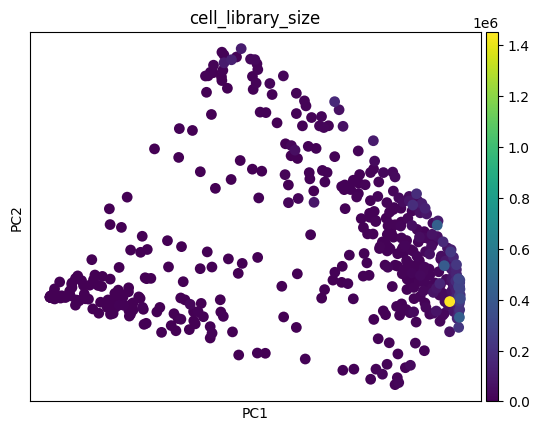

In [26]:
sc.pl.pca(adata_T_T, color='cell_library_size', cmap='viridis') # top 2 pca components

In [27]:
sc.pp.neighbors(adata_norm)

/Users/nicholasdjedjos/miniconda3/envs/comp_bio_lab_homework_4/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 500 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/Users/nicholasdjedjos/miniconda3/envs/comp_bio_lab_homework_4/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
sc.tl.umap(adata_norm)

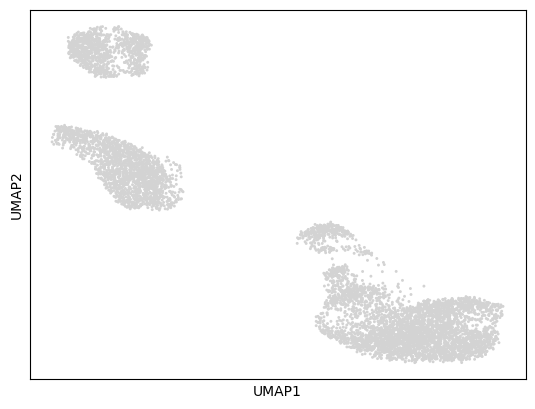

In [29]:
sc.pl.umap(adata_norm)

### 1a. Above, I scale to median library size, log transform the normalized data, perform PCA with 20 components, and then perform uMAP.

In [30]:
sum_of_variance_ratios = sum(adata_norm.uns['pca']['variance_ratio'])
print(sum_of_variance_ratios)

0.542835


### 1b. In this case, 20 PCs seem to capture the structure of the data well, as uMAP is able to extrapolate structure. However, 54.2% is a low variance ratio sum, and I'd be more comfortable with at least 80% of the variance explained.

In [31]:
from sklearn.cluster import KMeans


In [32]:
adata_norm

AnnData object with n_obs × n_vars = 6825 × 500
    var: 'cell_library_size'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Text(0.5, 1.0, 'Elbow curve')

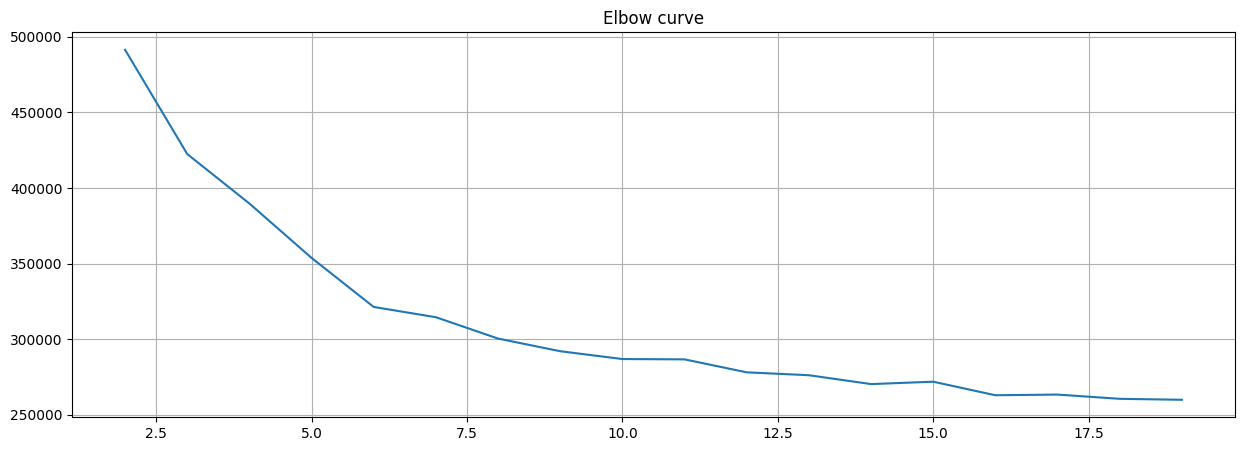

In [33]:
X = adata_norm.obsm['X_pca']
distorsions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    distorsions.append(kmeans.inertia_) 
    # kmeans.inertia_ measures how well a dataset is clusterd by k means

fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 20), distorsions)
plt.grid(True)
plt.title('Elbow curve')

In [34]:
# can try 5,3,6,10

In [35]:
def kmeans(cluster_number,X_pca,adata):
    output = KMeans(n_clusters=cluster_number, random_state=0).fit(X_pca)
    adata.obs[f'kmeans{cluster_number}'] = output.labels_.astype(str)


In [36]:
kmeans(5,X,adata_norm)

In [37]:
kmeans(3,X,adata_norm)
kmeans(6,X,adata_norm)
kmeans(10,X,adata_norm)

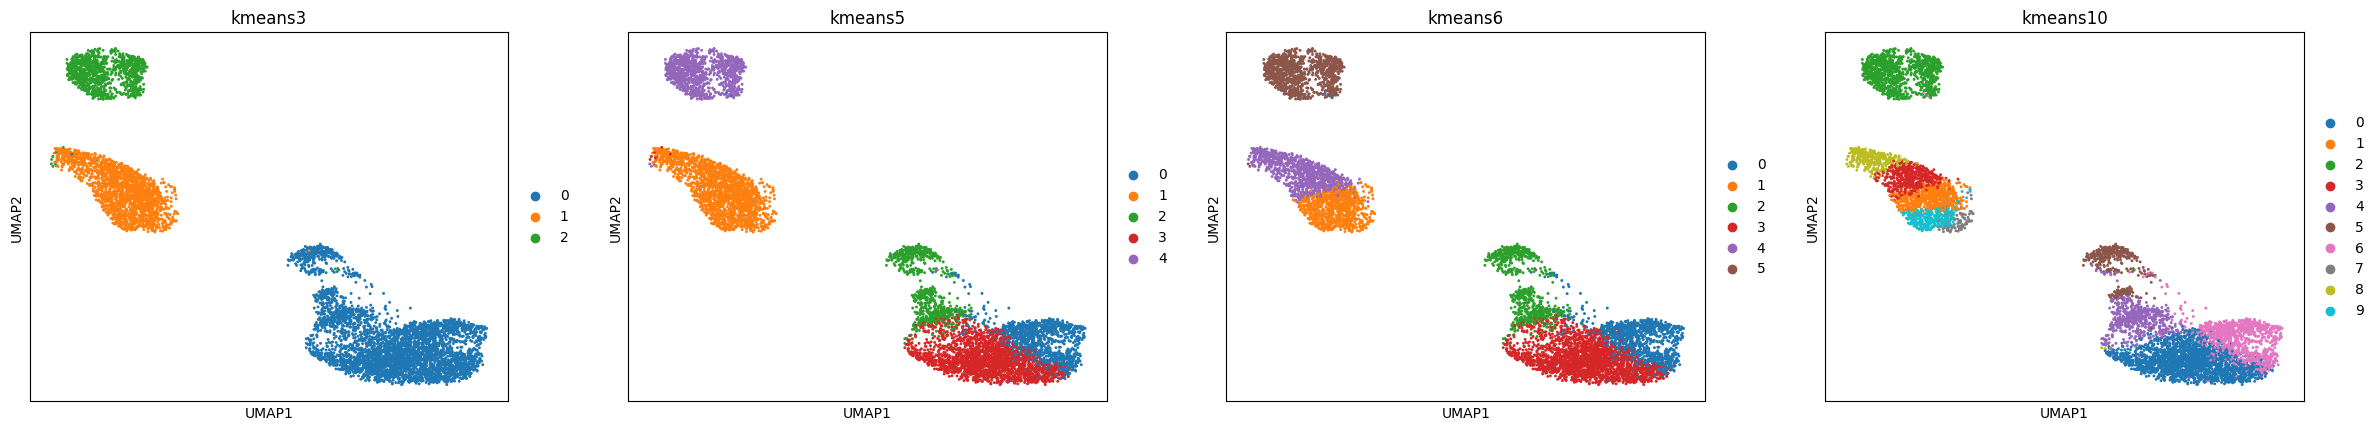

In [38]:
sc.pl.umap(adata_norm, color= ['kmeans3','kmeans5', 'kmeans6','kmeans10'])

### 2. Above is the output of my kmeans clustering. I would choose to use K=6 because I think it makes clusters with the most uniformity. I also used the elbow curve method to find where clusters that had a small sum of square distances between the centroids and other points and six appears to be the most natural elbow point. Obviously, with more clusers, there would be less sum of square distances between the points, but I also wanted to choose a cluster that appeared to fit the uMAP data.

In [39]:
# now doing the distance matrix stuff
sc.pp.neighbors(adata_norm, n_neighbors=30, metric='cosine')
adjacency_matrix = adata_norm.obsp['connectivities'].toarray()

<Axes: >

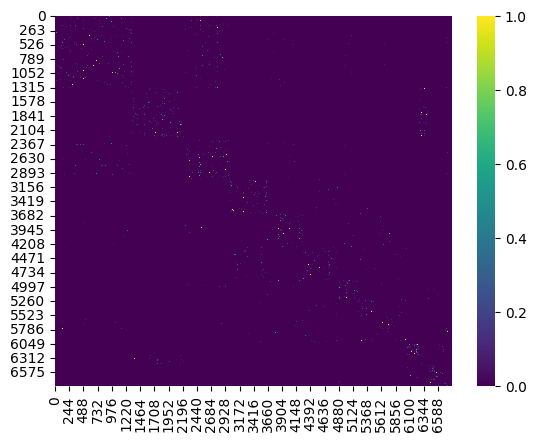

In [40]:
sns.heatmap(adjacency_matrix, cmap='viridis')

### 3. Above is my heatmap that I generated from a 30-nN between cells. I tested out different distance metrics (Euclidean, Manhattan) and decided to use cosine similarity. When I searched up "cosine similarity", I found that it's a mathematical way to look at the "direction" genes are expressed instead of their magnitude. I think this is important with analyzing gene expression data because we are looking for overall trends more than specific values (which would be captured by Euclidean distance).

In [41]:
adata_norm

AnnData object with n_obs × n_vars = 6825 × 500
    obs: 'kmeans5', 'kmeans3', 'kmeans6', 'kmeans10'
    var: 'cell_library_size'
    uns: 'pca', 'neighbors', 'umap', 'kmeans3_colors', 'kmeans5_colors', 'kmeans6_colors', 'kmeans10_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [42]:
sc.tl.louvain(adata_norm)

ModuleNotFoundError: No module named 'louvain'

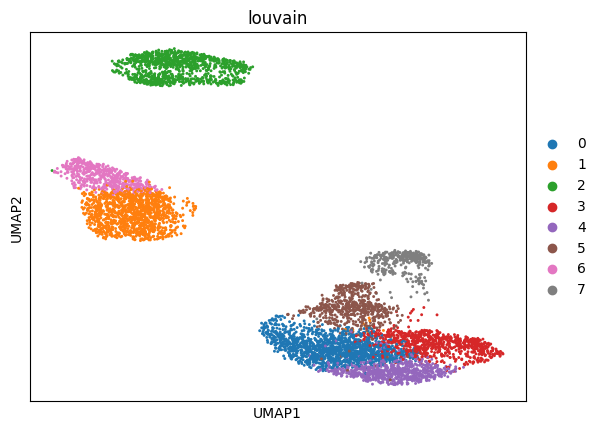

In [ ]:
sc.pl.umap(adata_norm, color='louvain')

### 4. The Louvain method appeared to identify eight clusters, while with Kmeans I chose to use has 6 clusters. For Louvain, I notice that the bottom right cluster, has six different characterizations, but visually, it looks like there are only 3 or 4. I think KMeans performed better with the six clusters visually than Louvain, but the process of hiearchical clustering with Louvain makes it good for analyzing relationships between cells in a network (like perhaps cellular transitions or cell types) so Louvain makes more sense mathematically. If I had to choose a method based off these results and their underlying mechanisms, I would move forward with the Louvain clustering method because it makes more sense biologically, while k-Means appears to be more of a broader appreoach to clustering. To fully interpret this graph, it would be important to know the different types of cell types expected to be from this sample.

In [ ]:
# choosing cluster zero
# don't do t-test on a specific cluster, do it on all of them and then choose a cluster to find DEG
# adata_0 = adata_norm[adata_norm.obs['louvain'] == '0']

In [ ]:
# at first I performed the t-test on just a cluster, but then I realized it would make more 
# sense to perform the t-test on ALL the clusters then choose a cluster to find DEG
sc.tl.rank_genes_groups(adata_norm,'louvain',method='t-test')

In [ ]:
x = adata_norm.uns['rank_genes_groups']['names']

In [ ]:
len(x)

500

In [ ]:
# 500 genes
len(x[0])

8

In [ ]:
print(x[1]) # most differentially expressed gene in each cluster. curious about cluster 2. how many should I go for

('CD3E', 'FTL', 'CD79A', 'IL32', 'RPS6', 'IL32', 'FTL', 'KLRD1')


In [ ]:
differentially_expressed_genes = []
for i in range(5): # only want the first 5 in cluster 2
    differentially_expressed_genes.append(x[i][2])
    

In [ ]:
print(len(differentially_expressed_genes))

5


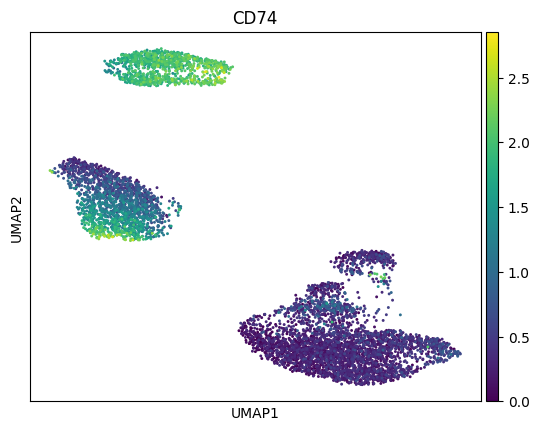

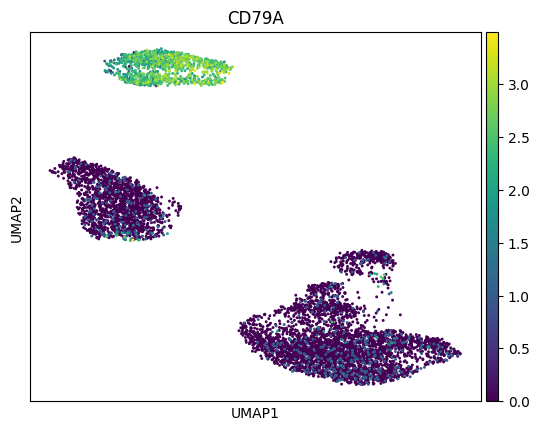

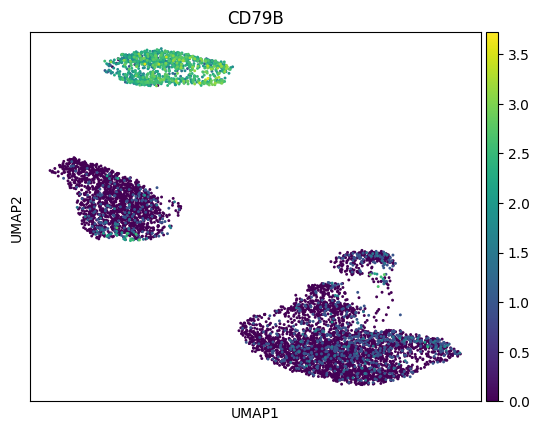

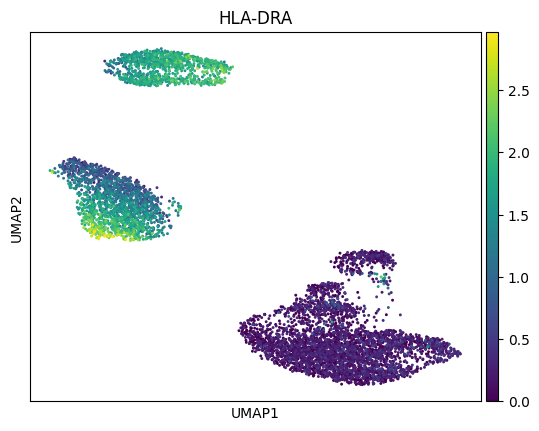

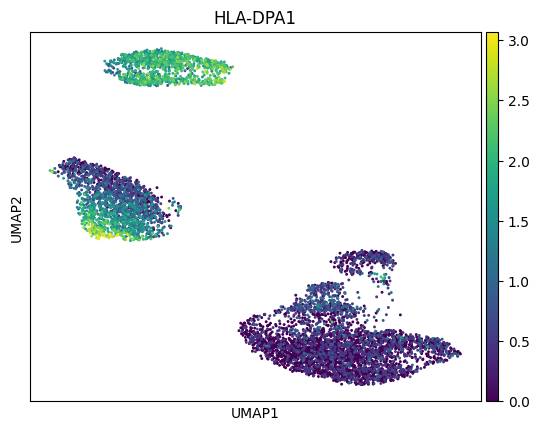

In [ ]:
for i in differentially_expressed_genes:
    sc.pl.umap(adata_norm,color=i,title=i)

### 5a. Above are the 5 DEG within cluster 2, which is the top most cluster. I'm surprised that there seems to be high expression in cluster 0 for HLA-DPA1, HLA-DRA and CD74. This makes me think that they could be similar cell types (perhaps both are Antigen Presenting Cells (APC)). 

### 5b. I would characterize the cluster as B cells because of the increased expression in CD74 and CD79A/CD79B especially. These genes are used for antigen presenting.

### 5c. Another way to differentially express genes that might be more robust than a t-test would be a non-parametric test like Wilxocon rank-sum test(Mann-Whitney U Test), Kruskal-Wallis, Kolmogorov-Smirnov test, which would convert gene expression to ranks and then test to see the if the distribution of ranks for one group are significantly different. One downside to this would be as the ranks get closer and closer together, it might be arbitrarily ranking one gene higher than another (like if one gene had expression 0 and so did another, ranking the two would be random).